# reff behavioral traces (newest run)

Loads the **most recent** trajectory pickle for the `reff_pg` run and makes the P(stop) vs
(consecutive failures, cumulative rewards) plots from the final cell of
`behavioral_gru_offset_indep_offsets_and_decays.ipynb` -- one per patch type. Run the imports cell
once, then the block below; it auto-finds the newest pickle (no path to edit).

In [20]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics_across_dfs,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    plot_stay_prob_distance_difference,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    plot_first_patch_rewards_vs_other_prefactors,
    plot_rewards_by_patch_sequence,
    odor_colors,
)
from aux_funcs import format_plot, zero_pad
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


plotting behavioral trace for pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_belief_32_dim_v3/trajectories_20260819_232641.pkl
Session data loaded
Session summaries generated
plotting behavioral trace for pickle: ../../../results/reff_pg_markov_persistence_longer_interpatch/trajectories_20260820_231353.pkl
Session data loaded
Session summaries generated
plotting behavioral trace for pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_no_belief/trajectories_20260901_211448.pkl
Session data loaded
Session summaries generated


/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:1308: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_c, ax_c = plt.subplots(figsize=figsize, dpi=300 if high_res_save else 100)


plotting behavioral trace for pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_no_belief_clean_ms0p25/trajectories_20260903_083951.pkl
Session data loaded
Session summaries generated
plotting behavioral trace for pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_no_belief_clean_ms0p5/trajectories_20260903_090656.pkl
Session data loaded
Session summaries generated


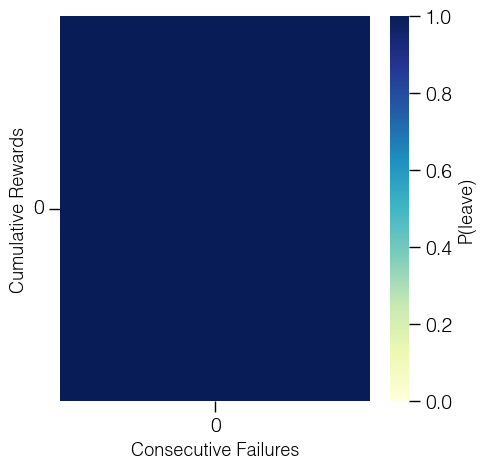

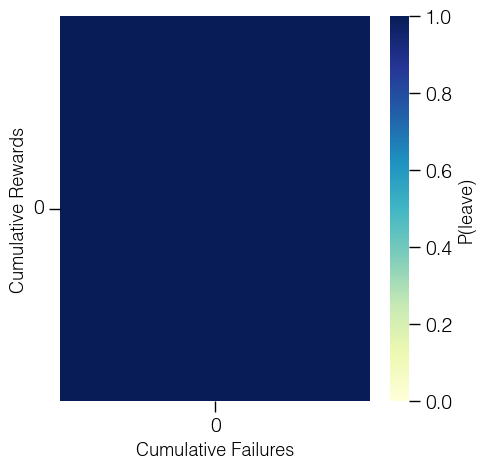

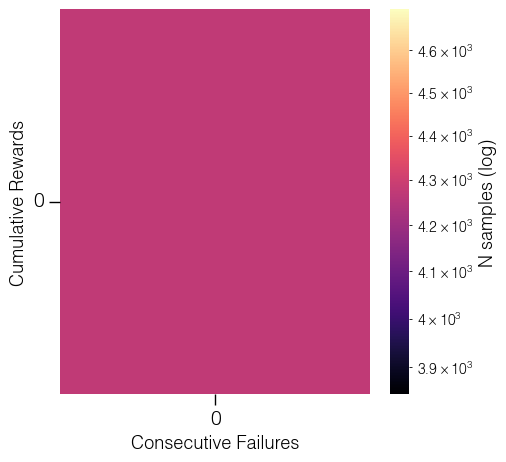

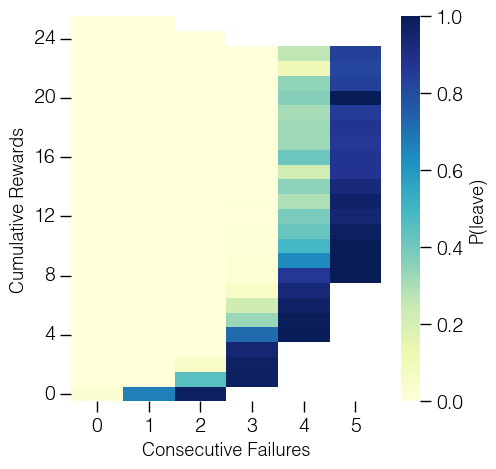

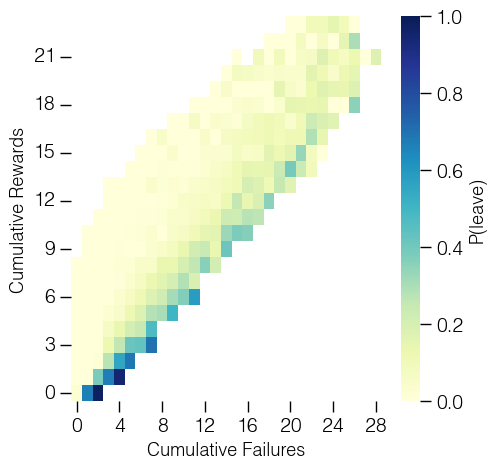

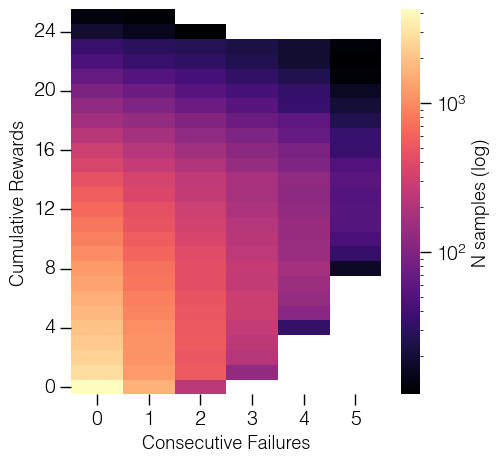

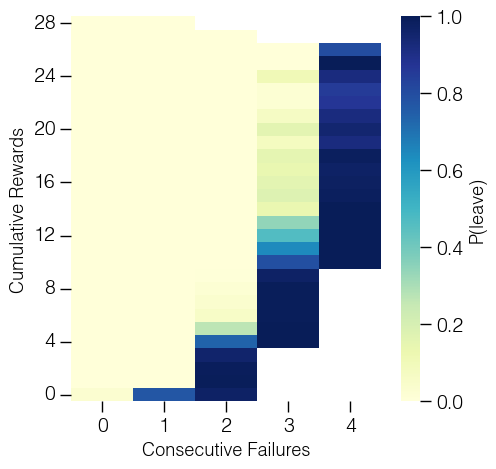

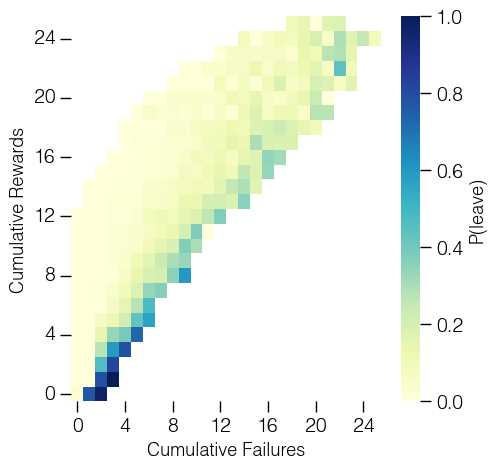

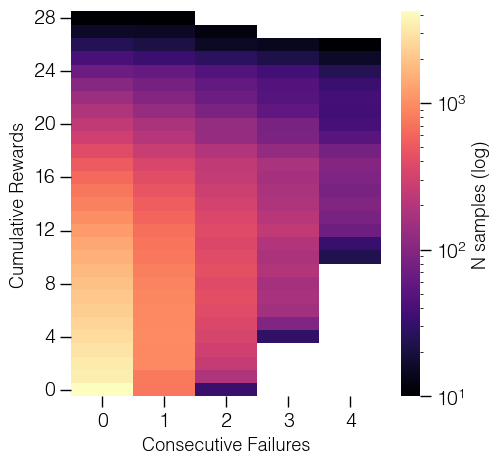

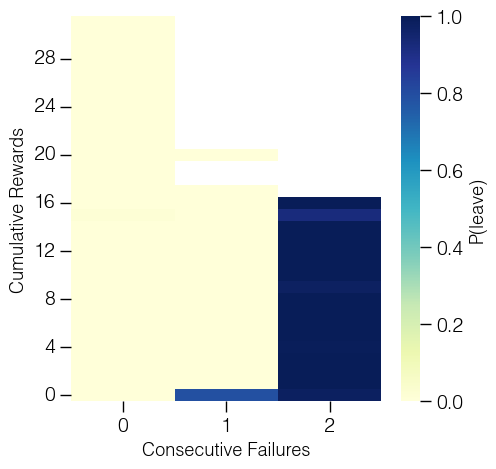

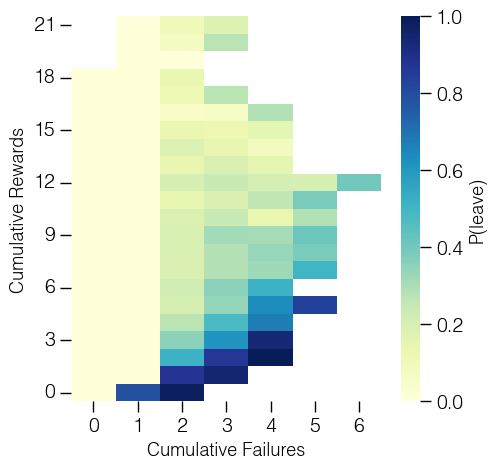

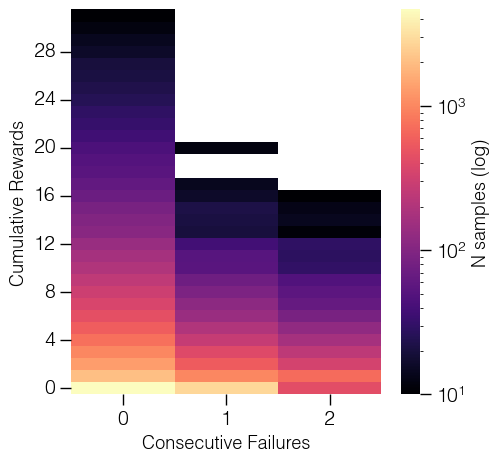

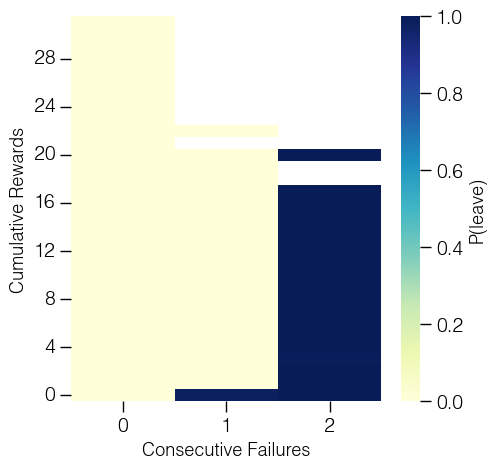

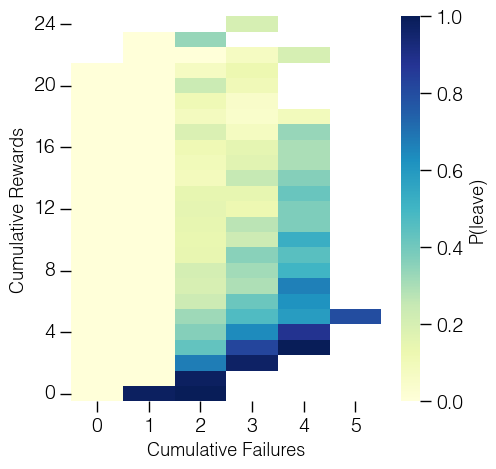

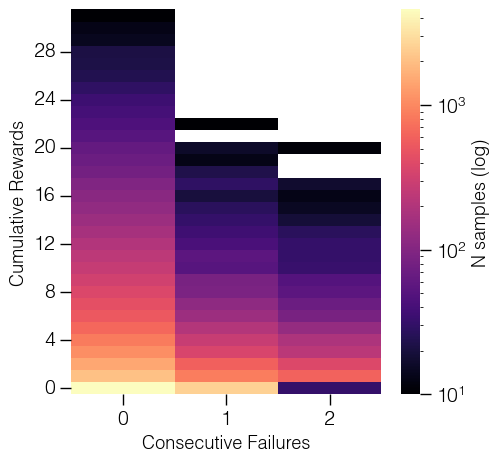

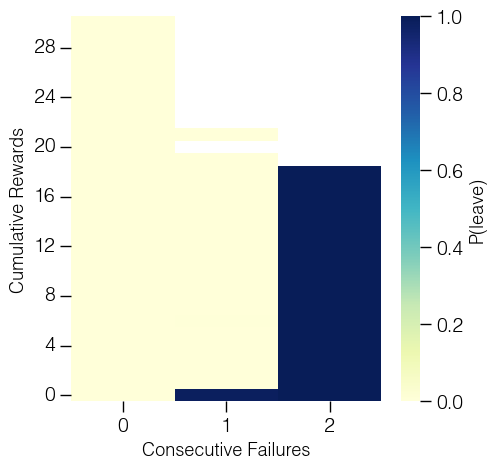

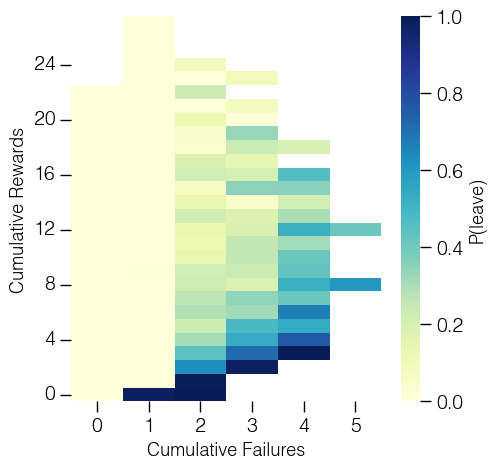

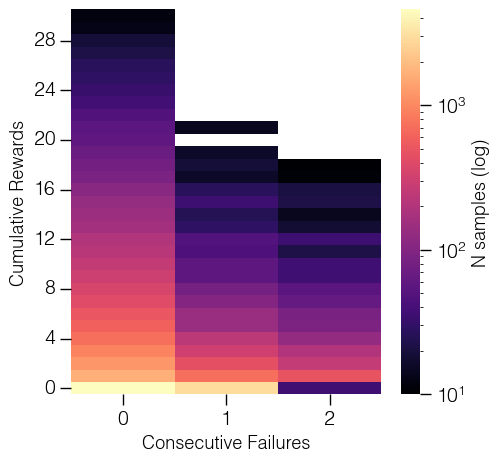

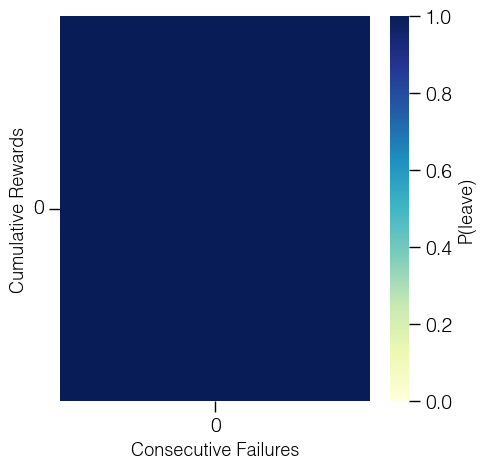

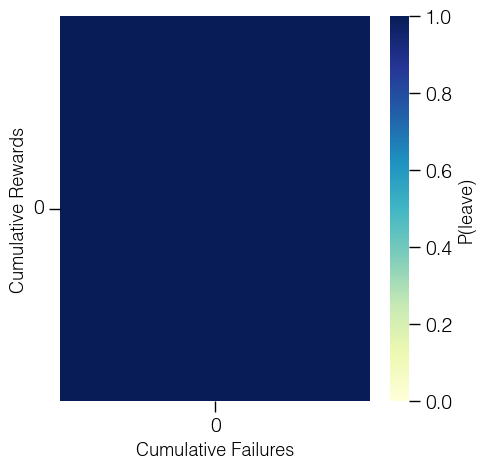

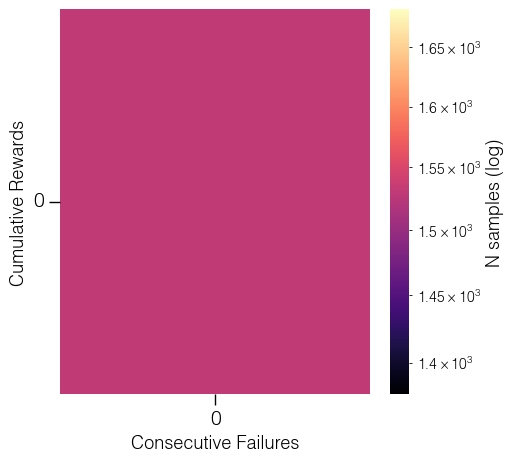

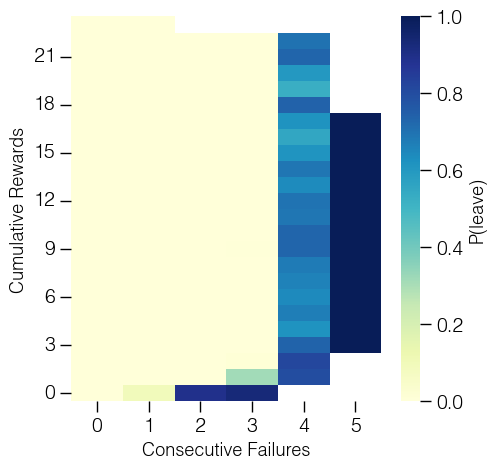

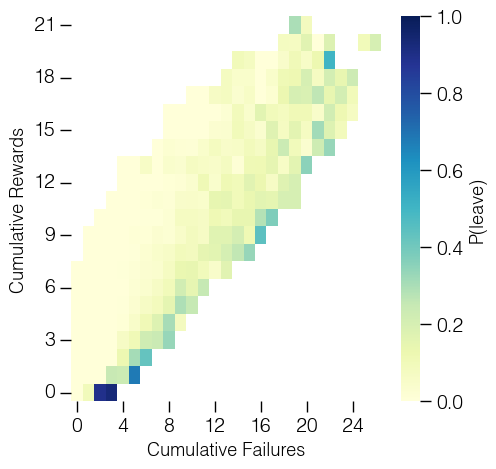

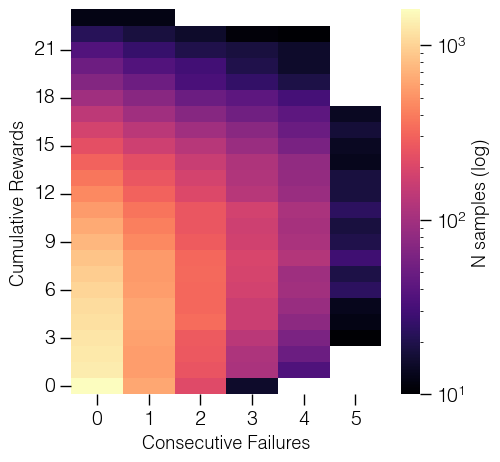

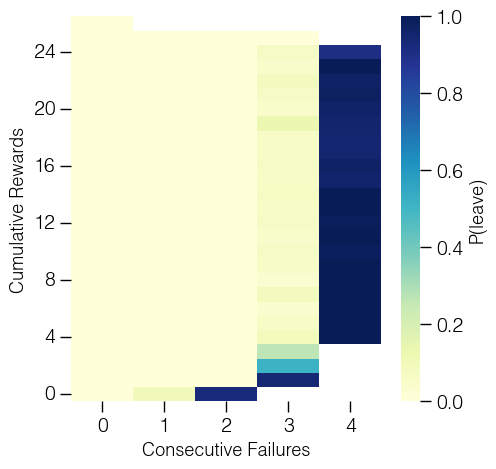

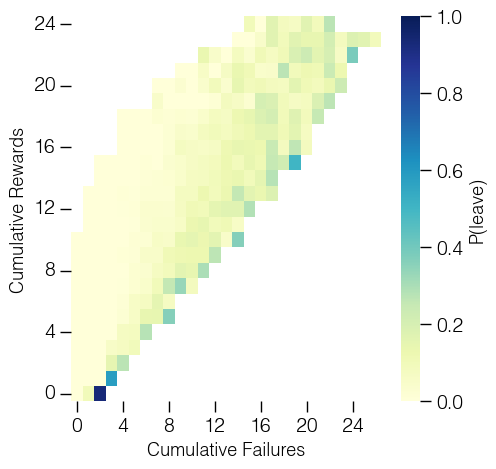

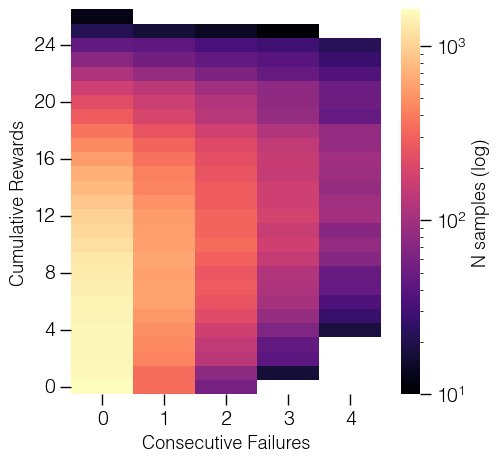

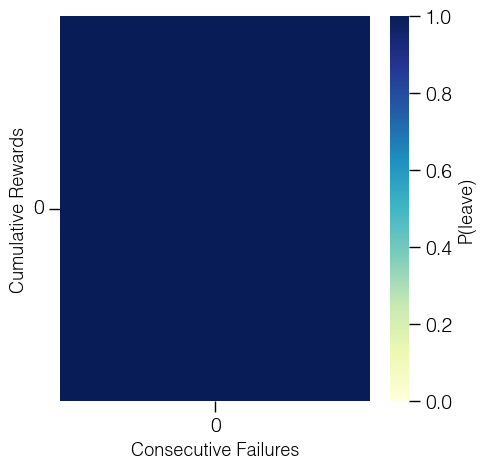

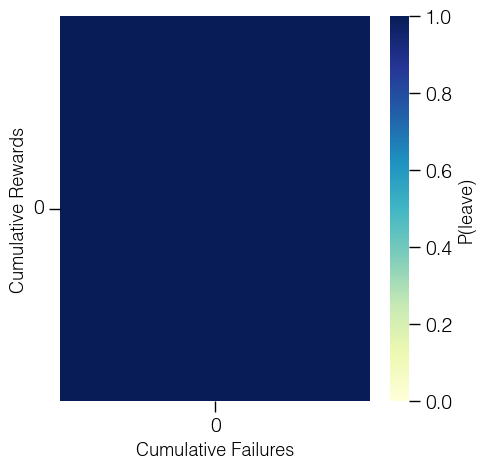

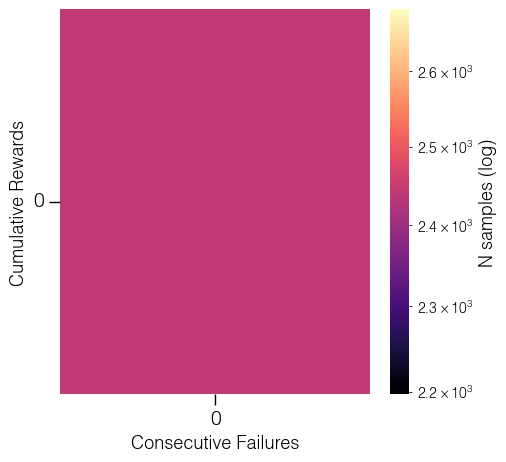

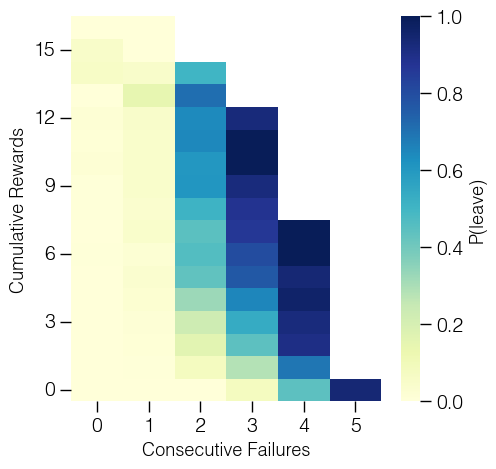

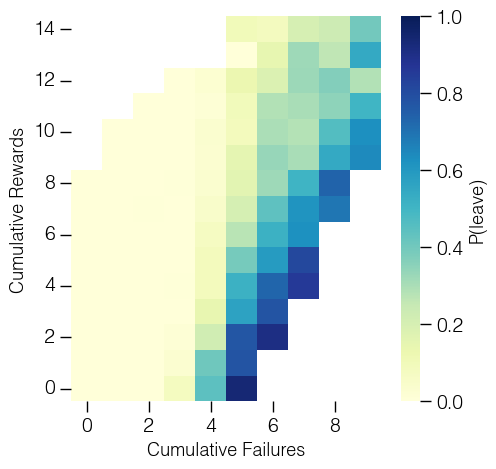

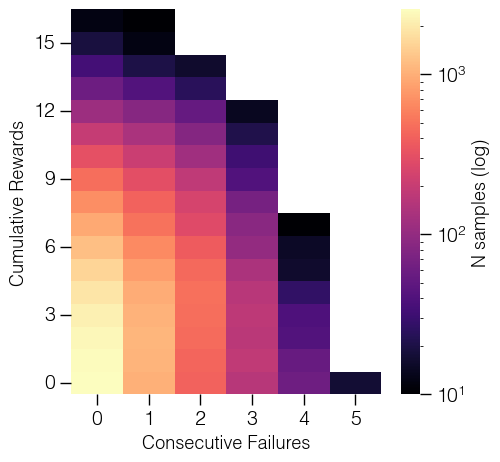

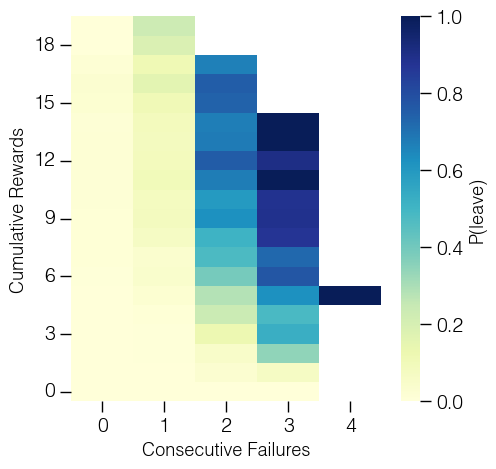

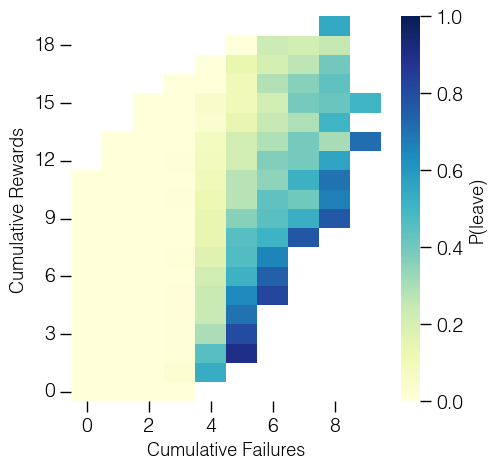

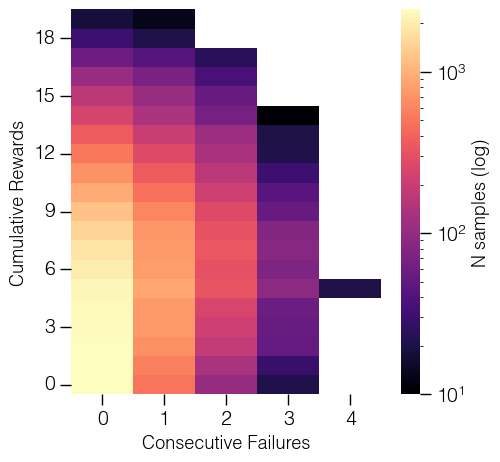

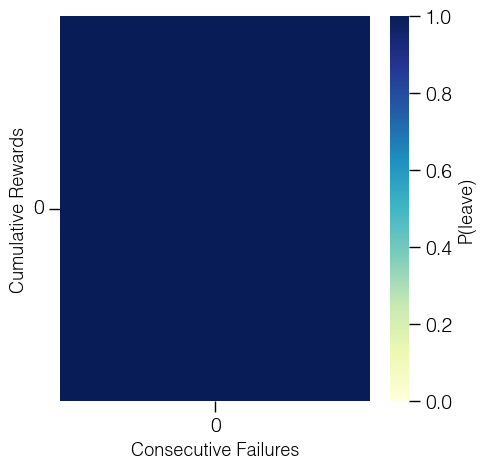

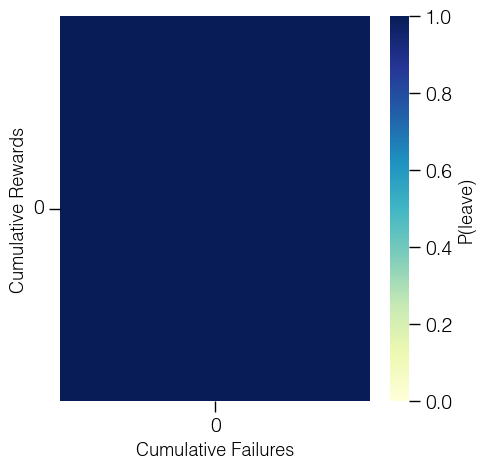

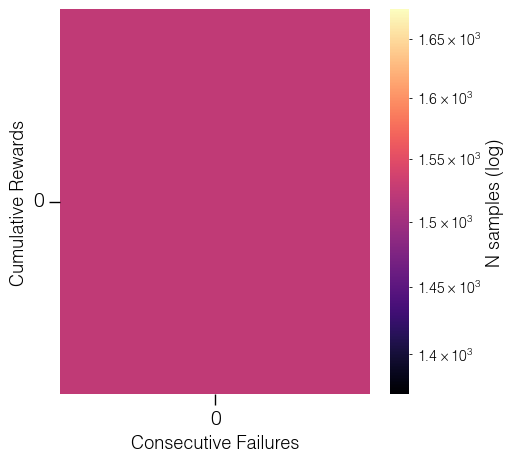

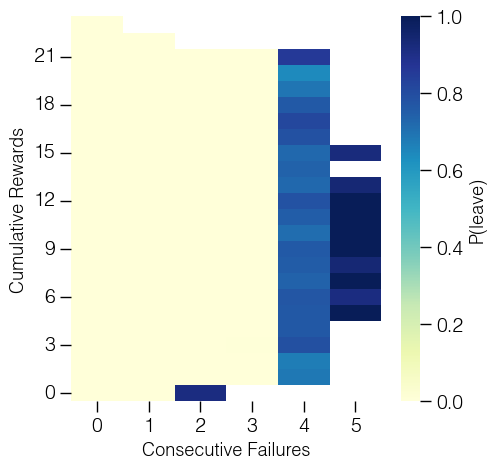

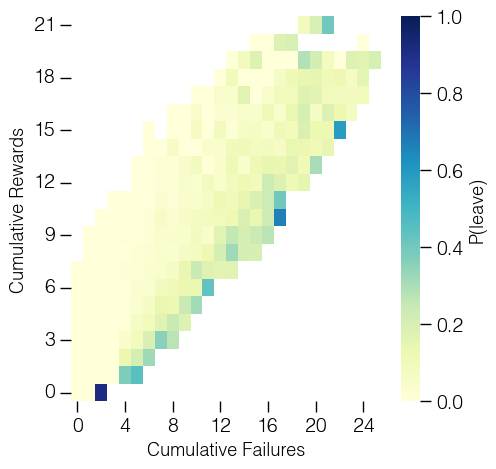

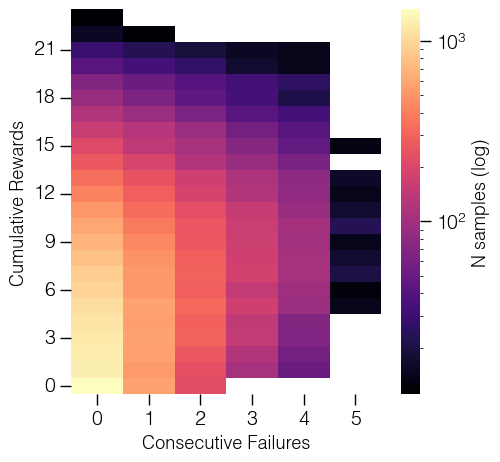

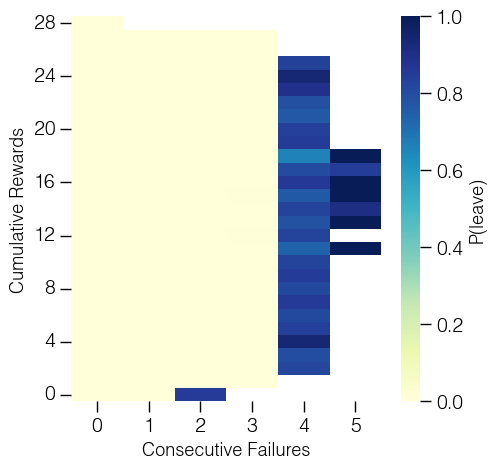

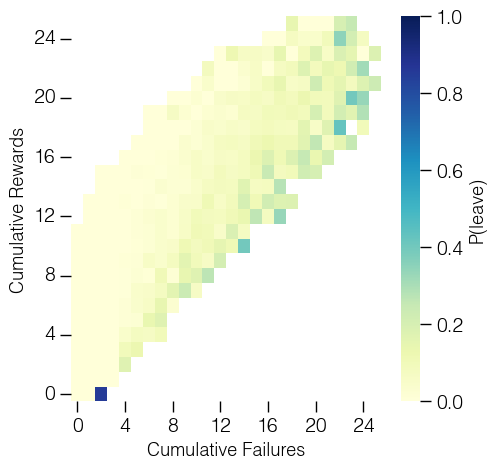

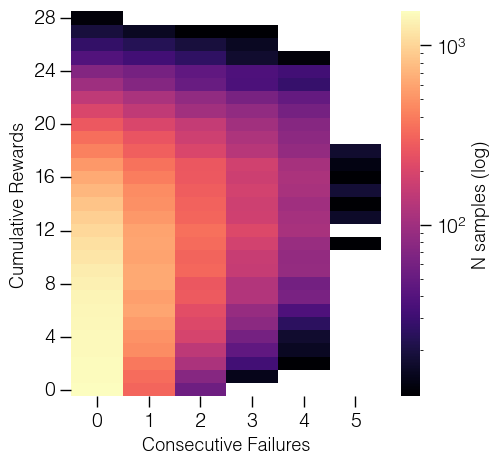

In [21]:
import glob

# --- point at the reff run; find the MOST RECENT trajectory pickle in its directory ---------------
# EXP = 'reff_pg_exp_gru_initial_prob_offset_belief_32_dim_v3'
EXPS = [
    'reff_pg_exp_gru_initial_prob_offset_belief_32_dim_v3',
    'reff_pg_markov_persistence_longer_interpatch',
    'reff_pg_exp_gru_initial_prob_offset_no_belief',
    'reff_pg_exp_gru_initial_prob_offset_no_belief_clean_ms0p25',
    'reff_pg_exp_gru_initial_prob_offset_no_belief_clean_ms0p5',
]
all_cands = []
for exp in EXPS:
    RESULTS = f'../../../results/{exp}'
    cands = glob.glob(f'{RESULTS}/trajectories/*.pkl') + glob.glob(f'{RESULTS}/trajectories*.pkl')
    assert cands, f'no trajectory pickle found under {RESULTS} (has the run saved a snapshot yet?)'
    for data_path in [c for c in sorted(cands, key=os.path.getmtime)][-1:]:
        print('plotting behavioral trace for pickle:', data_path)
        df = load_odor_site_df(data_path, nn_num=0)

        # --- final-cell plots: P(stop) heatmap over (consecutive failures x cumulative rewards) per patch ---
        for patch_type in (0, 1, 2,):
            plot_stop_fraction(
                df,
                'consecutive_misses',
                'rewards_seen_in_patch',
                invert_y=True,
                condition=lambda x, pt=patch_type: x[x['patch_type'] == pt],
                figsize=(5, 5),
                reverse=True,
                xlabel='Consecutive Failures',
                ylabel='Cumulative Rewards',
                # vmax=0.7,
                min_n=10,
            )
    all_cands.append(cands)


plotting behavioral trace for newest pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_belief_32_dim_v3/trajectories_20260819_232641.pkl
[0.  0.6 0.8]
plotting behavioral trace for newest pickle: ../../../results/reff_pg_markov_persistence_longer_interpatch/trajectories_20260820_231353.pkl
[0.02172089 0.36828327 0.7244698 ]
plotting behavioral trace for newest pickle: ../../../results/reff_pg_exp_gru_initial_prob_offset_no_belief/trajectories_20260901_211448.pkl
[0.  0.6 0.8]


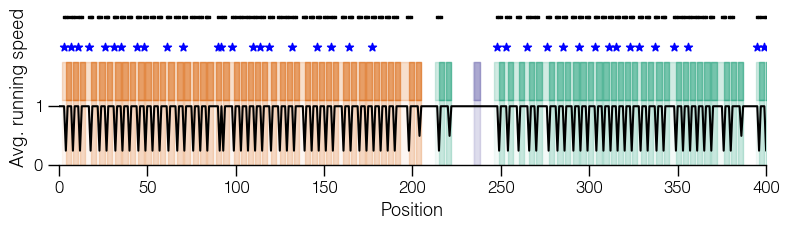

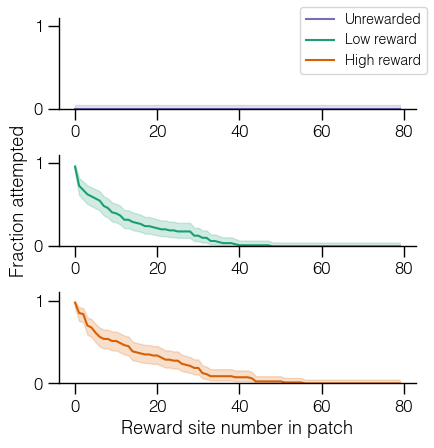

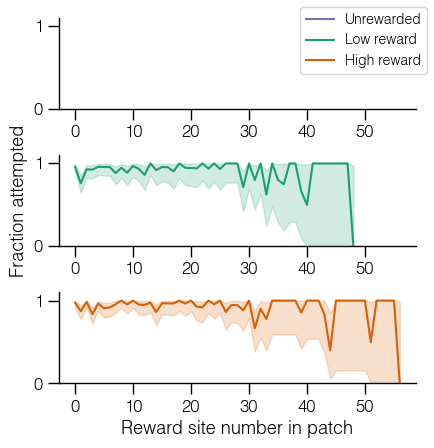

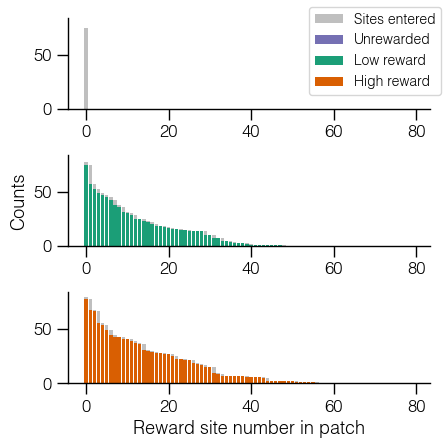

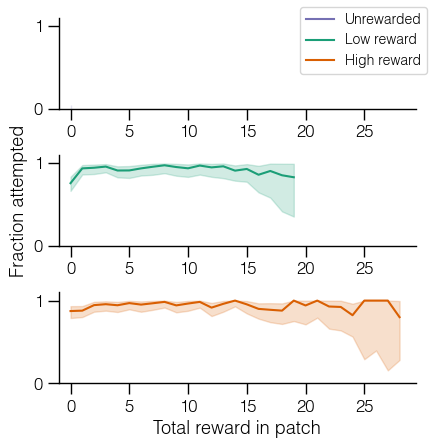

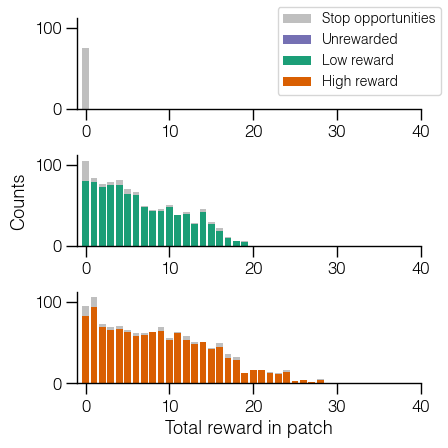

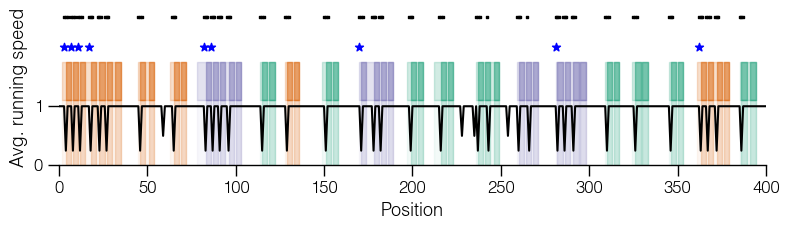

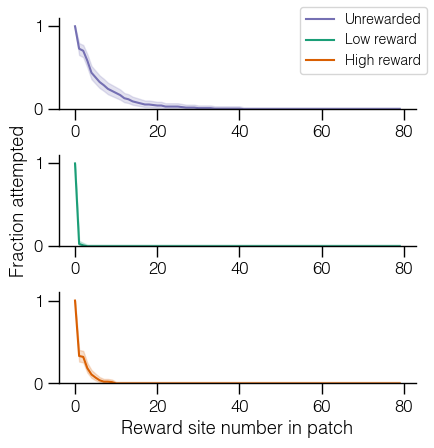

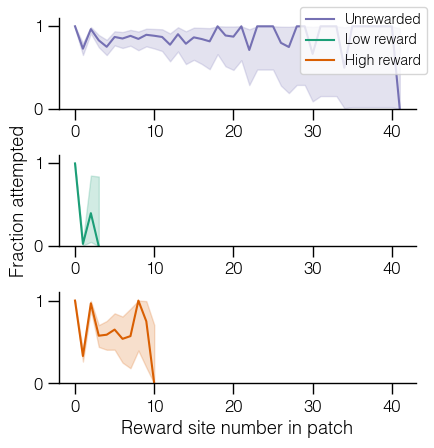

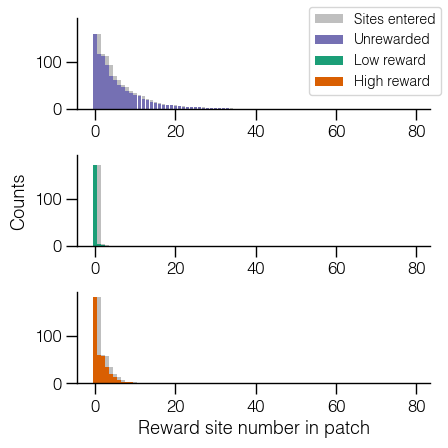

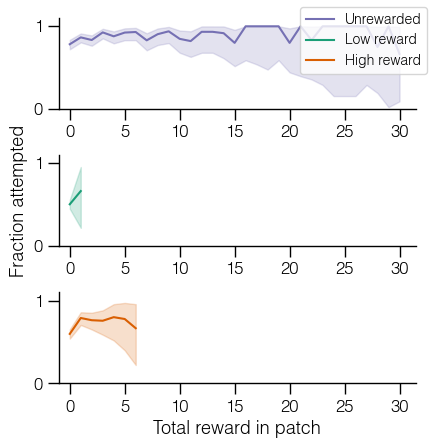

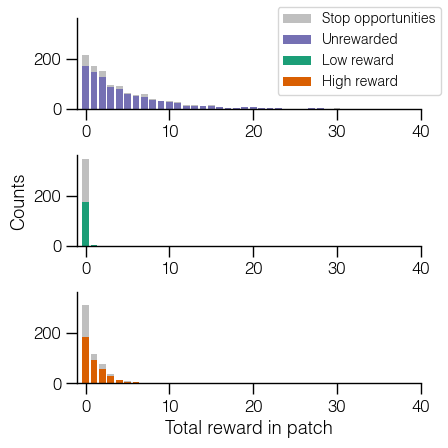

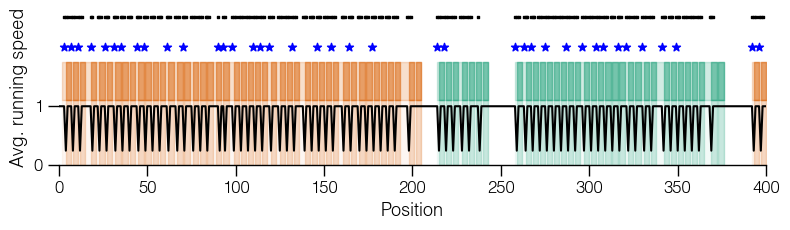

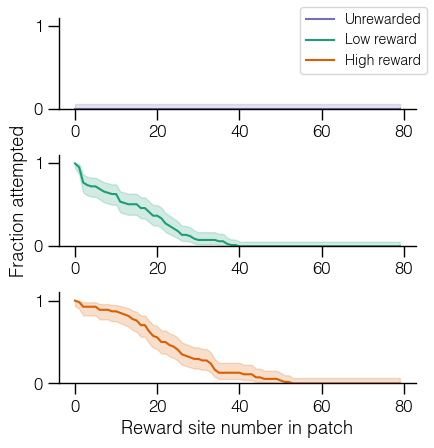

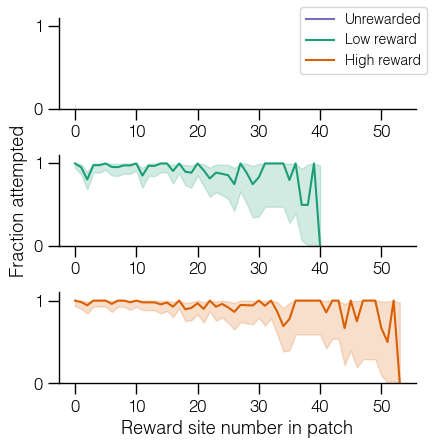

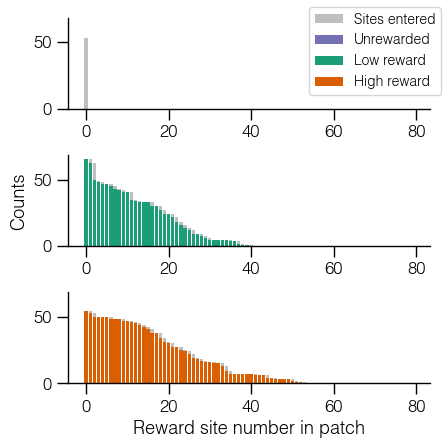

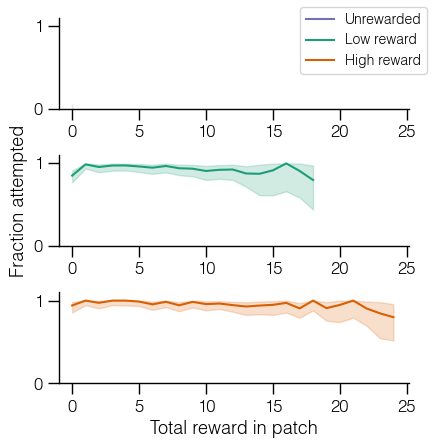

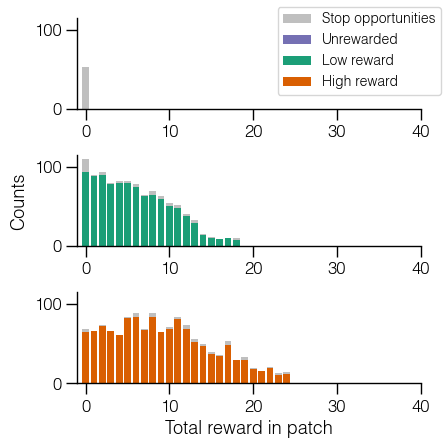

In [ ]:
# Behavioral trace of one session (params modeled on behavioral_gru_offset_indep_offsets_and_decays).
# Uses `data_path` (the newest pickle) found in the block above.
for cands in all_cands:
    data_path = max(cands, key=os.path.getmtime)
    print('plotting behavioral trace for newest pickle:', data_path)
    plot_session(
        data_path,
        session_idx=0,
        xlim=(0, 400),
        max_reward_param=40,
        max_reward_sites=80,
        use_fixed_colors=True,
        color_by_reward_param=False,
    )

NameError: name 'EXP' is not defined

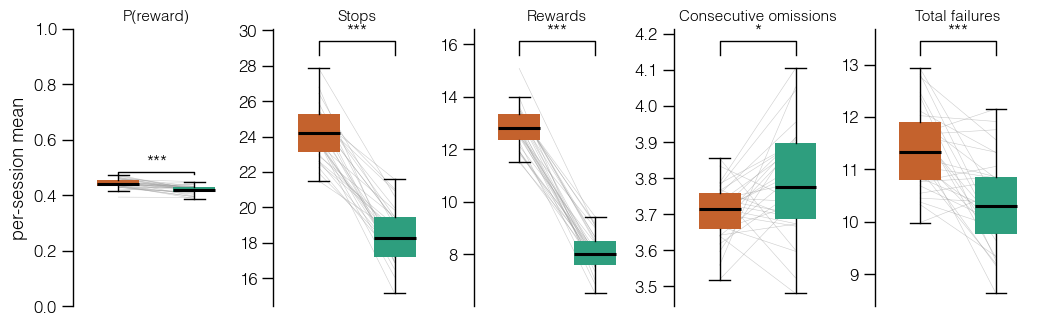

In [ ]:
# ===== patch-type 2 (orange) vs 1 (green) paired box plots, per session (reuses `df`) ===============
import numpy as np, pandas as pd
from scipy.stats import wilcoxon

def _patch_metrics(g):
    g = g.sort_values('index')
    pref = g['patch_reward_prob_prefactor'].to_numpy(); param = g['patch_reward_param'].to_numpy()
    rs = g['rewards_seen_in_patch'].to_numpy()
    p_reward = float(pref[-1] * np.exp(-rs[-1] / param[-1]))    # reward prob at the LEAVE site (last row)
    stops = float(g['stopped'].sum())
    rewards = float(rs.max())                                   # rewards_seen_in_patch (per your note)
    cons_om = float(g['consecutive_misses'].to_numpy()[-1])     # consecutive misses AT TIME OF LEAVING
    total_fail = float(max(stops - rewards, 0.0))
    return pd.Series({'P(reward)': p_reward, 'Stops': stops, 'Rewards': rewards,
                      'Consecutive omissions': cons_om, 'Total failures': total_fail,
                      'patch_type': int(g['patch_type'].iloc[0])})

metrics = ['P(reward)', 'Stops', 'Rewards', 'Consecutive omissions', 'Total failures']
per_patch = df.groupby(['session_number', 'patch_number'], sort=False).apply(_patch_metrics, include_groups=False).reset_index()
per_patch = per_patch[per_patch['patch_type'].isin([1, 2])]
per_sess = per_patch.groupby(['session_number', 'patch_type'])[metrics].mean().reset_index()   # mean over that type's patches
piv = {m: per_sess.pivot(index='session_number', columns='patch_type', values=m).dropna() for m in metrics}

def _stars(p): return 'ns' if p > 0.05 else ('*' if p > 1e-2 else ('**' if p > 1e-3 else '***'))
ORANGE, GREEN = '#C4622D', '#2E9E7E'
fig, axes = plt.subplots(1, len(metrics), figsize=(2.5*len(metrics), 3.6))
for ax, m in zip(axes, metrics):
    d = piv[m]; t2 = d[2].to_numpy(); t1 = d[1].to_numpy()
    for a, b in zip(t2, t1):
        ax.plot([1, 2], [a, b], color='0.6', lw=0.4, alpha=0.5, zorder=1)
    bp = ax.boxplot([t2, t1], positions=[1, 2], widths=0.55, patch_artist=True, showfliers=False, zorder=2,
                    medianprops=dict(color='k', lw=2.2), whiskerprops=dict(color='k'),
                    capprops=dict(color='k'), boxprops=dict(edgecolor='none'))
    bp['boxes'][0].set_facecolor(ORANGE); bp['boxes'][1].set_facecolor(GREEN)
    try: pval = wilcoxon(t2, t1).pvalue
    except ValueError: pval = 1.0
    top = float(np.concatenate([t2, t1]).max()); bot = float(np.concatenate([t2, t1]).min())
    h = (top - bot) * 0.06 + 1e-9
    ax.plot([1, 1, 2, 2], [top+h, top+2*h, top+2*h, top+h], color='k', lw=1)
    ax.text(1.5, top+2*h, _stars(pval), ha='center', va='bottom', fontsize=13)
    ax.set_title(m, fontsize=11); ax.set_xticks([]); ax.set_xlim(0.4, 2.6)
axes[0].set_ylabel('per-session mean')
format_plot(axes, bottomspine=False, set_xticks_bottom=False)
axes[0].set_ylim(0, 1)   # P(reward) on a 0-1 scale
fig.suptitle(f'{EXP}   (orange = patch type 2, green = patch type 1;  paired by session, n = {len(piv["Stops"])})', fontsize=10)
plt.tight_layout(); plt.show()

for m in metrics:
    d = piv[m]
    try: pv = wilcoxon(d[2], d[1]).pvalue
    except ValueError: pv = 1.0
    print(f'{m:24s} type2 {d[2].mean():7.3f}   type1 {d[1].mean():7.3f}   p = {pv:.2e}  ({_stars(pv)})')
